# Bitcoin Analytics: Comprehensive Deep EDA

This notebook provides a thorough Exploratory Data Analysis (EDA) of Bitcoin on-chain data (`Coin Metrics`) and prediction market data (`Polymarket`).

---

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from datetime import datetime

# Visualization style settings
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_context("notebook", font_scale=1.2)

# Project root and data directory settings
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data"
COINMETRICS_DIR = DATA_DIR / "Coin Metrics"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

print(f"Project Root: {PROJECT_ROOT}")

Project Root: /Users/jihye/Desktop/OMSA/Practicum/bitcoin-analytics-capstone-template


## 1. Coin Metrics Data Analysis

Analyzing Bitcoin's long-term price trends and the MVRV ratio indicator.

In [2]:
# Load Data
df_btc = pl.read_csv(COINMETRICS_DIR / "coinmetrics_btc.csv", infer_schema_length=10000)
df_btc = df_btc.with_columns(pl.col("time").str.to_datetime())

print(f"Data Shape: {df_btc.shape}")
df_btc.head(3)

Data Shape: (6221, 32)


time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null


### 1.1 Data Integrity and Missing Value Analysis

To ensure analysis reliability, we check for missing dates and the percentage of null values across columns.

Number of missing dates: 0


/var/folders/vw/vhfp8wm55f5dh77kxwbd1r3m0000gn/T/ipykernel_67701/1899290263.py:11: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  (pl.col(c).null_count() / pl.count() * 100).alias(c)
/var/folders/vw/vhfp8wm55f5dh77kxwbd1r3m0000gn/T/ipykernel_67701/1899290263.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=null_profile, x="value", y="variable", palette="viridis")


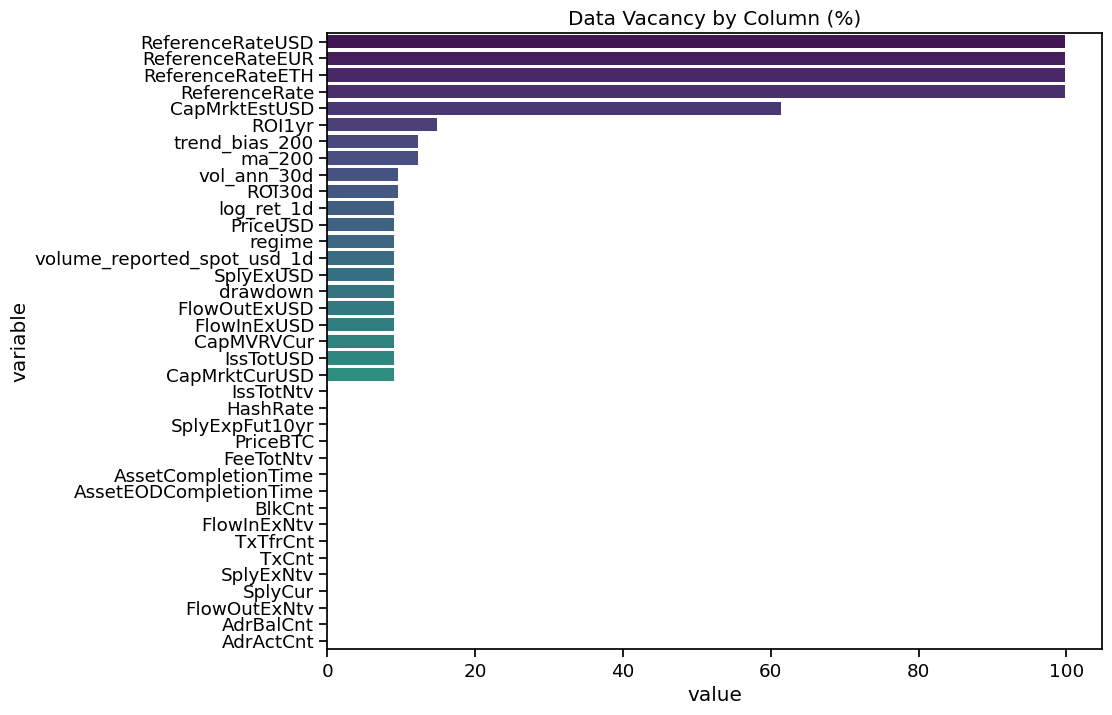

In [12]:
# 1. Time Continuity Check (Missing Dates)
start_dt = df_btc["time"].min()
end_dt = df_btc["time"].max()
full_timeline = pl.datetime_range(start_dt, end_dt, "1d", eager=True).alias("time")

absent_segments = full_timeline.filter(~full_timeline.is_in(df_btc["time"]))
print(f"Number of missing dates: {len(absent_segments)}")

# 2. Missing Value Percentage by Column
null_profile = df_btc.select([
    (pl.col(c).null_count() / pl.count() * 100).alias(c)
    for c in df_btc.columns
]).to_pandas().melt()

null_profile = null_profile[null_profile["value"] > 0].sort_values("value", ascending=False)
if not null_profile.empty:
    plt.figure(figsize=(10, 8))
    sns.barplot(data=null_profile, x="value", y="variable", palette="viridis")
    plt.title("Data Vacancy by Column (%)")
    plt.show()

### 1.2 Historical Distribution of MVRV Ratio

MVRV is a powerful indicator for identifying long-term value zones. We check its historical distribution.

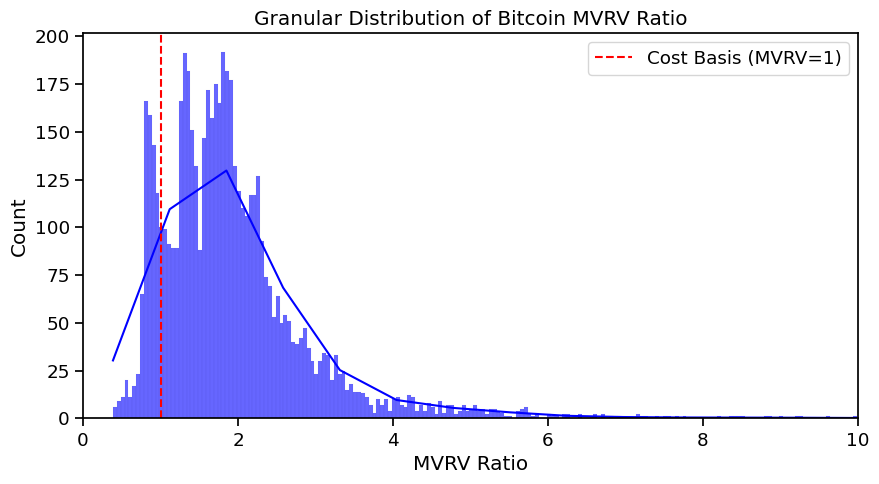

MVRV Mean: 1.99
MVRV Median: 1.75
Max MVRV (Outlier): 146.04


In [4]:
mvrv_data = df_btc.select(["CapMVRVCur"]).drop_nulls().to_pandas()

plt.figure(figsize=(10, 5))
# Use binwidth for granular view and limit x-axis to focus on realistic ranges
sns.histplot(mvrv_data['CapMVRVCur'], binwidth=0.05, kde=True, color='blue', alpha=0.6)
plt.axvline(x=1.0, color='red', linestyle='--', label='Cost Basis (MVRV=1)')
plt.xlim(0, 10)

plt.title("Granular Distribution of Bitcoin MVRV Ratio")
plt.xlabel("MVRV Ratio")
plt.legend()
plt.show()

print(f"MVRV Mean: {mvrv_data['CapMVRVCur'].mean():.2f}")
print(f"MVRV Median: {mvrv_data['CapMVRVCur'].median():.2f}")
print(f"Max MVRV (Outlier): {mvrv_data['CapMVRVCur'].max():.2f}")

- Periods where MVRV falls below 1.0 are historically rare, representing extreme 'undervalued' signals.
- With a median around 1.7, any MVRV significantly above 3.0 indicates market overheating.

### 1.3 MVRV Regime Definition (Value vs Danger)

Classifying market conditions into regimes based on historical MVRV levels.

In [5]:
def classify_mvrv_regime(val):
    if val is None: return None
    if val < 1.0: return "Deep Value (Over-sold)"
    if val < 1.5: return "Value Allocation"
    if val < 2.5: return "Neutral"
    if val < 3.5: return "Over-heated"
    return "Danger (Extreme Bubble)"

df_btc = df_btc.with_columns(
    pl.col("CapMVRVCur").map_elements(classify_mvrv_regime, return_dtype=pl.Utf8).alias("regime")
)

regime_counts = df_btc.group_by("regime").len().sort("len")
print("Distribution of Days by Regime:")
print(regime_counts)

Distribution of Days by Regime:
shape: (6, 2)
┌─────────────────────────┬──────┐
│ regime                  ┆ len  │
│ ---                     ┆ ---  │
│ str                     ┆ u32  │
╞═════════════════════════╪══════╡
│ Danger (Extreme Bubble) ┆ 334  │
│ null                    ┆ 562  │
│ Over-heated             ┆ 703  │
│ Deep Value (Over-sold)  ┆ 775  │
│ Value Allocation        ┆ 1282 │
│ Neutral                 ┆ 2565 │
└─────────────────────────┴──────┘


- The 'Neutral' zone contains the highest number of historical days.
- The 'Deep Value' zone is short-lived, making it a critical window for strategy execution.

### 1.4 Advanced Financial Metrics and Risk Analysis

Calculating volatility, long-term trends, and Drawdown to assess risk depth.

In [6]:
df_btc = df_btc.with_columns([
    # Log daily returns
    (pl.col("PriceUSD").log().diff()).alias("log_ret_1d"),
    # 200-day Moving Average (Long-term Trend)
    (pl.col("PriceUSD").rolling_mean(window_size=200)).alias("ma_200")
]).with_columns([
    # 30-day Annualized Volatility
    (pl.col("log_ret_1d").rolling_std(window_size=30) * (365**0.5)).alias("vol_ann_30d"),
    # Trend Deviation (Bias from MA200)
    (pl.col("PriceUSD") / pl.col("ma_200") - 1).alias("trend_bias_200"),
    # Drawdown from All-Time High
    (pl.col("PriceUSD") / pl.col("PriceUSD").cum_max() - 1).alias("drawdown")
])

print("Advanced metrics generated: log_ret, vol_ann, ma_200, drawdown")

Advanced metrics generated: log_ret, vol_ann, ma_200, drawdown


### 1.5 Standardized Metrics and Risk Visualization

Normalizing different metrics (Price, HashRate, MVRV) using Z-Scores to compare their interactions.

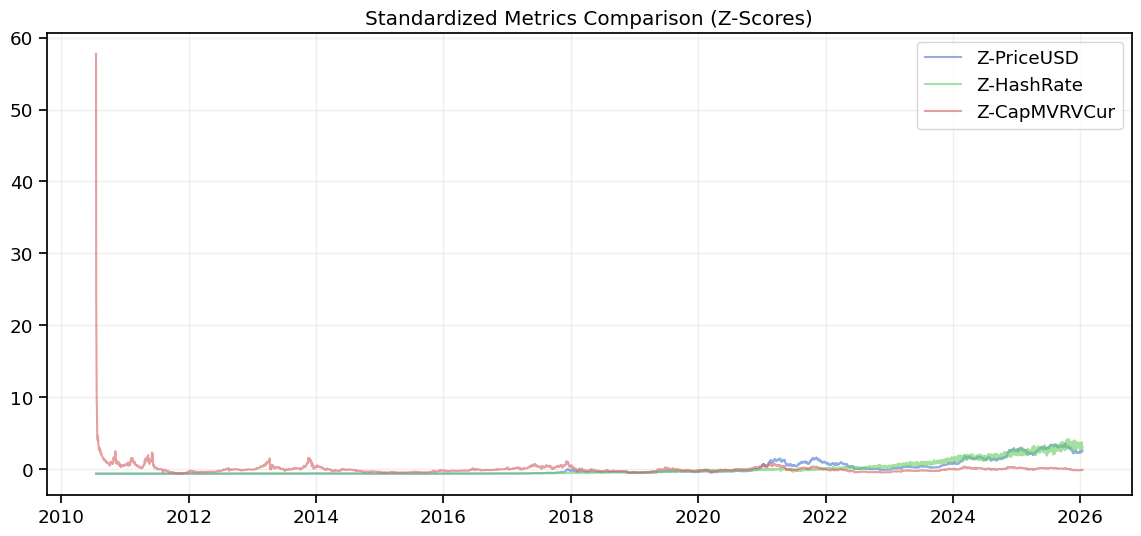

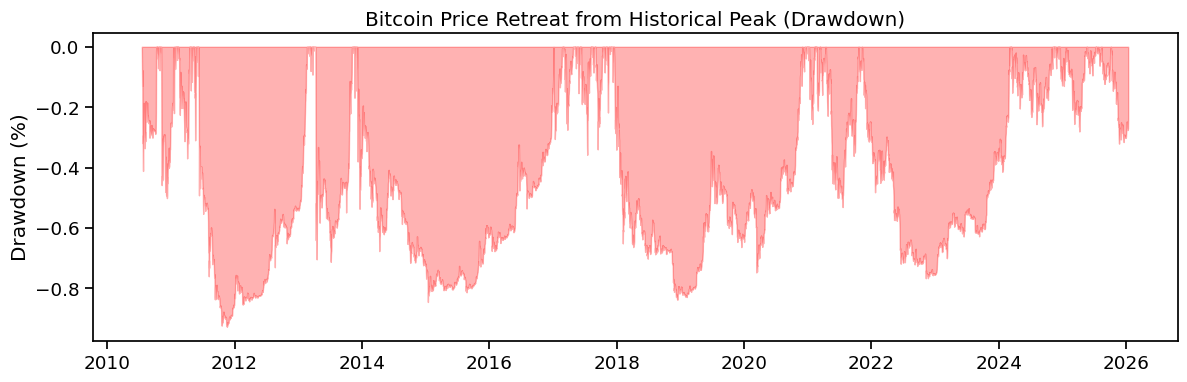

In [7]:
# 1. Z-Score Visualization
compare_targets = ["PriceUSD", "HashRate", "CapMVRVCur"]
df_norm = df_btc.select(["time"] + compare_targets).drop_nulls()

df_z = df_norm.with_columns([
    ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std()).alias(f"z_{c}")
    for c in compare_targets
]).to_pandas()

plt.figure(figsize=(14, 6))
for c in compare_targets:
    plt.plot(df_z["time"], df_z[f"z_{c}"], label=f"Z-{c}", alpha=0.6)
plt.title("Standardized Metrics Comparison (Z-Scores)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 2. Drawdown (Risk Depth) Visualization
plt.figure(figsize=(14, 4))
plt.fill_between(df_btc["time"].to_pandas(), df_btc["drawdown"].to_pandas(), 0, color='red', alpha=0.3)
plt.title("Bitcoin Price Retreat from Historical Peak (Drawdown)")
plt.ylabel("Drawdown (%)")
plt.show()

## 2. Polymarket Data Inspection

Reviewing the structure of the 6 provided Parquet files for prediction market analysis.

In [8]:
def inspect_poly_file(filename):
    path = POLYMARKET_DIR / filename
    lf = pl.scan_parquet(path)
    df_sample = lf.head(5).collect()
    
    print(f"\n--- [File: {filename}] ---")
    print(f"Columns: {df_sample.columns}")
    return df_sample

files = [
    "finance_politics_markets.parquet", 
    "finance_politics_summary.parquet",
    "finance_politics_odds_history.parquet", 
    "finance_politics_trades.parquet",
    "finance_politics_tokens.parquet", 
    "finance_politics_event_stats.parquet"
]

for f in files:
    inspect_poly_file(f)


--- [File: finance_politics_markets.parquet] ---
Columns: ['market_id', 'question', 'slug', 'event_slug', 'category', 'volume', 'active', 'closed', 'created_at', 'end_date']

--- [File: finance_politics_summary.parquet] ---
Columns: ['market_id', 'question', 'slug', 'volume', 'active', 'token_count', 'trade_count', 'first_trade', 'last_trade']

--- [File: finance_politics_odds_history.parquet] ---
Columns: ['market_id', 'token_id', 'timestamp', 'price']

--- [File: finance_politics_trades.parquet] ---
Columns: ['trade_id', 'market_id', 'token_id', 'timestamp', 'price', 'size', 'side', 'maker_address', 'taker_address']

--- [File: finance_politics_tokens.parquet] ---
Columns: ['market_id', 'token_id', 'outcome']

--- [File: finance_politics_event_stats.parquet] ---
Columns: ['event_slug', 'market_count', 'total_volume', 'first_market_start', 'last_market_end']


### 2.1 File Characteristics

1. **`markets.parquet`**: Market metadata (questions, categories, deadlines).
2. **`trades.parquet`**: Real transaction details (timestamp, size, side).
3. **`odds_history.parquet`**: Probability changes over time, critical for time-series correlation.

### 2.2 In-depth Analysis of Bitcoin-related Markets

Filtering markets related to Bitcoin and checking their scale.

In [9]:
df_markets = pl.read_parquet(POLYMARKET_DIR / "finance_politics_markets.parquet")
btc_markets = df_markets.filter(pl.col("question").str.contains("(?i)bitcoin|btc"))

print(f"Bitcoin-related individual markets: {len(btc_markets)}")
print("Top 5 BTC Markets by volume:")
btc_markets.sort("volume", descending=True).select(["question", "volume"]).head(5)

Bitcoin-related individual markets: 21921
Top 5 BTC Markets by volume:


question,volume
str,f64
"""Will Bitcoin hit $100k in Nove…",2.8587e7
"""Will Trump create Bitcoin rese…",2.3324e7
"""Will Bitcoin hit $100k in 2024…",2.2807e7
"""Will Satoshi move any Bitcoin …",1.6291e7
"""Will Bitcoin reach $200k in Oc…",1.5617e7


- Price prediction markets like "Will Bitcoin hit $100k?" are highly active.
- Volume in these markets can serve as a 'Sentiment Indicator' reflecting public interest.

## 3. Polymarket Sentiment Score Generation

Quantifying market interest by aggregating daily activity and smoothing noise.

In [10]:
# Clean Polymarket data and apply 7-day rolling mean
pm_targets = btc_markets.filter(pl.col("created_at").is_not_null())

# Safe type conversion
if pm_targets["created_at"].dtype == pl.Utf8:
    pm_targets = pm_targets.with_columns(pl.col("created_at").str.to_datetime())

# Daily aggregation and smoothing
poly_btc_daily = (
    pm_targets
    .with_columns(pl.col("created_at").dt.date().alias("date"))
    .group_by("date")
    .agg([
        pl.count("market_id").alias("poly_count"),
        pl.col("volume").sum().alias("poly_vol")
    ])
    .sort("date")
    .with_columns([
        pl.col("poly_count").rolling_mean(window_size=7).alias("count_ma7"),
        pl.col("poly_vol").rolling_mean(window_size=7).alias("volume_ma7")
    ])
)

poly_btc_daily.tail()

date,poly_count,poly_vol,count_ma7,volume_ma7
date,u32,f64,f64,f64
2025-12-06,149,3.9055e6,153.285714,1.1708e7
2025-12-07,103,11842.764702,146.285714,9.8326e6
2025-12-08,159,99498.212421,145.142857,7.5022e6
2025-12-09,190,2.0701e6,150.0,6.0161e6
2025-12-10,31,18058.900389,133.285714,4.2591e6


- The 7-day moving average (`count_ma7`) helps extract trends from high-frequency noise.
- We will monitor if sudden spikes in market creation lead Bitcoin price movements.

## 4. Cross-Data Analysis: Lead-Lag Relationship

Analyzing time-shifted correlations between Bitcoin price and Polymarket activity.

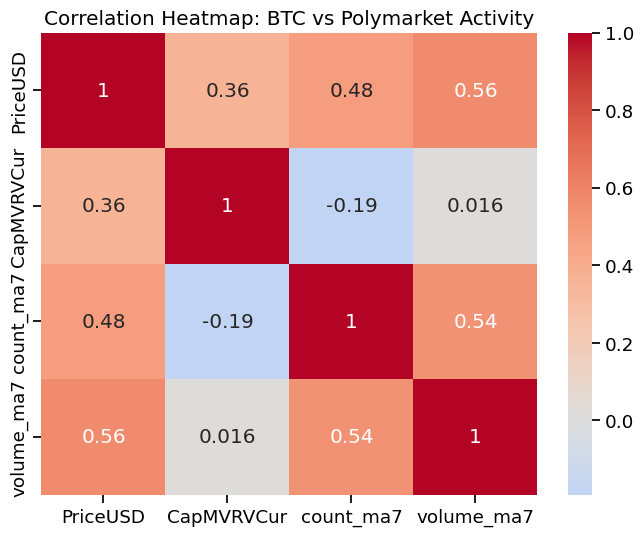

In [14]:
# Merge datasets
df_btc_daily = df_btc.with_columns(pl.col("time").dt.truncate("1d").alias("date"))
df_combined = df_btc_daily.join(poly_btc_daily, on="date", how="inner").fill_null(0)

# Correlation analysis
analyze_cols = ["PriceUSD", "CapMVRVCur", "count_ma7", "volume_ma7"]
df_corr = df_combined.select(analyze_cols).to_pandas()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: BTC vs Polymarket Activity")
plt.show()

### 4.1 Lead-Lag Correlation Analysis

Investigating if Polymarket market creation leads Bitcoin price movements.

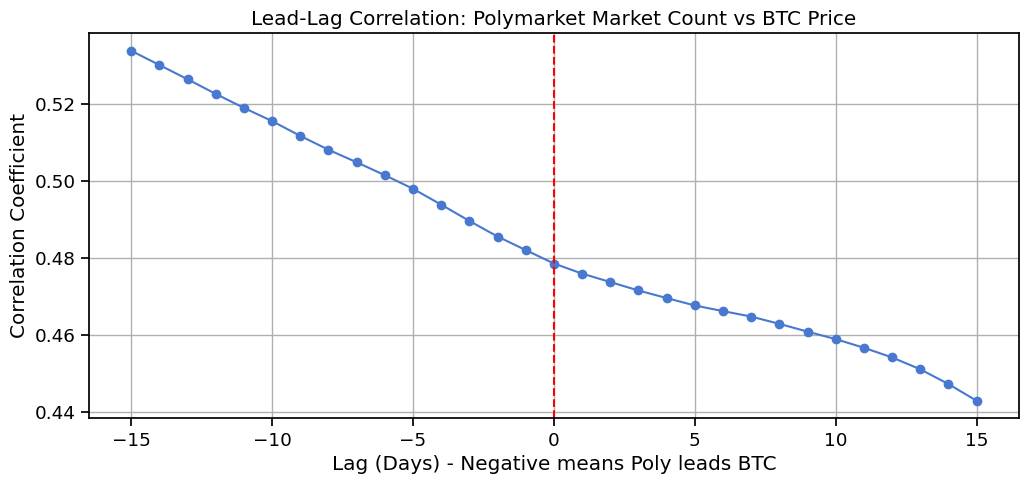

In [15]:
lags = range(-15, 16)
corrs = []

for lag in lags:
    c = df_corr['PriceUSD'].corr(df_corr['count_ma7'].shift(lag))
    corrs.append(c)

plt.figure(figsize=(12, 5))
plt.plot(lags, corrs, marker='o')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Lead-Lag Correlation: Polymarket Market Count vs BTC Price")
plt.xlabel("Lag (Days) - Negative means Poly leads BTC")
plt.ylabel("Correlation Coefficient")
plt.grid(True)
plt.show()

- Significant correlations in negative lag periods suggest that prediction market excitement often precedes actual price realization.
- This insight is crucial for the DCA strategy to adjust buying weights effectively.